In [1]:
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
unoDF = pd.read_csv('../SDCardOut/uno/concurrentUNO1.CSV')
noMagDF = pd.read_csv('../SDCardOut/uno/noMagFullUNO.CSV')

In [3]:
unoDF['seconds'] = pd.to_numeric(unoDF['seconds'],errors='coerce')
unoDF['sensor'] = pd.to_numeric(unoDF['sensor'],errors='coerce')
noMagDF['seconds'] = pd.to_numeric(noMagDF['seconds'],errors='coerce')
noMagDF['sensor'] = pd.to_numeric(noMagDF['sensor'],errors='coerce')

unoSens = unoDF['sensor'].to_numpy(dtype=float)
unoSecs = unoDF['seconds'].to_numpy(dtype=float)
noMagSens = noMagDF['sensor'].to_numpy(dtype=float)
noMagSecs = noMagDF['seconds'].to_numpy(dtype=float)

In [4]:
unoVolt = unoSens*5/16383
noMagVolt = noMagSens*5/16383

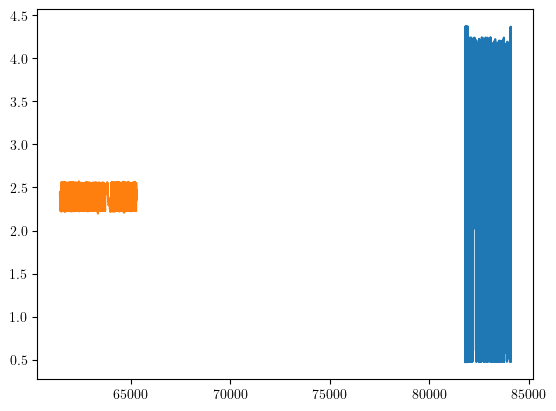

In [5]:
plt.plot(unoSecs,unoVolt)
plt.plot(noMagSecs,noMagVolt)

In [6]:
np.isnan(unoVolt).argmax()

np.int64(0)

In [7]:
unoF,unoPSD = welch(unoVolt,fs=100,nperseg=300)
noMagF,noMagPSD = welch(noMagVolt,fs=100,nperseg=300)

In [8]:
unoPSD

array([0.25497323, 1.06561016, 0.51217824, 0.19864775, 0.1264664 ,
       0.06662621, 0.02484448, 0.01194099, 0.0090618 , 0.00824631,
       0.00580045, 0.00517894, 0.00524954, 0.00484759, 0.00413605,
       0.00408999, 0.00413177, 0.00295331, 0.00309378, 0.00421981,
       0.0050283 , 0.00634584, 0.00571313, 0.00555715, 0.0067675 ,
       0.00529161, 0.00557305, 0.00664305, 0.00694769, 0.0099266 ,
       0.00976979, 0.00734223, 0.00475498, 0.00346733, 0.0019464 ,
       0.00226344, 0.00279656, 0.0041637 , 0.00362829, 0.00278584,
       0.00399309, 0.00365822, 0.00259185, 0.003097  , 0.00430007,
       0.00374513, 0.00286275, 0.00290035, 0.00263368, 0.00340854,
       0.00370148, 0.00500843, 0.00322622, 0.00308054, 0.00272145,
       0.00220787, 0.00225672, 0.00349376, 0.00376458, 0.00224927,
       0.00305538, 0.00264375, 0.00244493, 0.00255656, 0.00200592,
       0.00236603, 0.00398311, 0.00377694, 0.00223389, 0.0023915 ,
       0.00270878, 0.00272345, 0.00233579, 0.00134778, 0.00201

Text(0, 0.5, 'V$^2$/Hz')

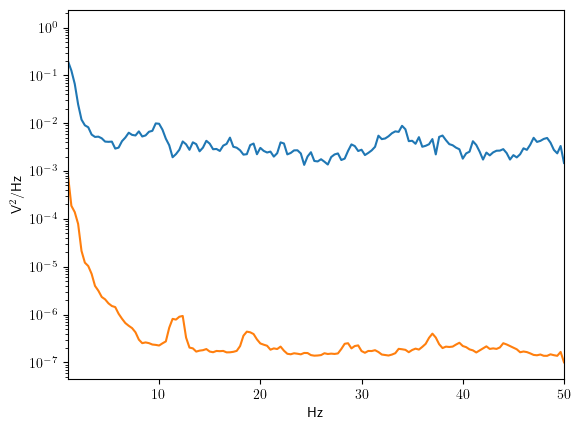

In [10]:
plt.plot(unoF,unoPSD)
plt.plot(noMagF,noMagPSD)
plt.xlim(1,50)
# plt.semilogx()
plt.semilogy()
plt.xlabel('Hz')
plt.ylabel("V$^2$/Hz")

[]

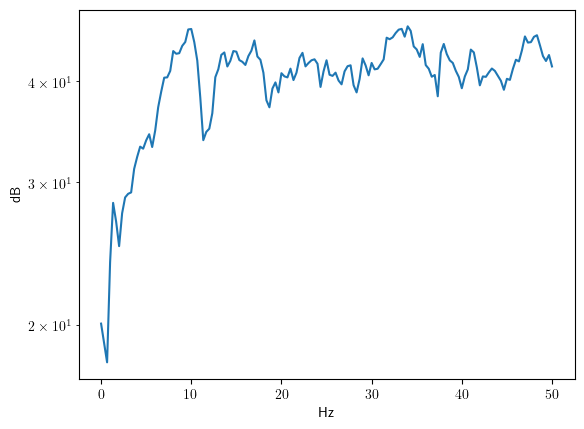

In [12]:
plt.plot(unoF,10*np.log10(unoPSD/noMagPSD))
plt.xlabel('Hz')
plt.ylabel('dB')
plt.semilogy()
